# Method B — 확장 엣지 × kw/ip 임계 격자 실험

**설계**: 3 엣지 조건 × 2 kw 임계 × 2 ip 임계 = 12셀 격자

| edges \ (kw, ip) | kw=5, ip=2 | kw=5, ip=1 | kw=3, ip=2 | kw=3, ip=1 |
|---|---|---|---|---|
| no new edges | exp21 ✓ 0.6867 | exp36 ✓ 0.6730 | exp22 ✓ 0.6744 | exp31 ✓ 0.6670 |
| +via_ip +ipip | exp32 ✓ 0.6717 | exp34 ✓ 0.6719 | exp38 ✓ 0.6943 | exp40 ✓ 0.6722 |
| +all new edges | exp33 ✓ 0.6659 | exp37 ✓ 0.6762 | exp39 ✓ 0.6881 | exp41 ✓ **0.6959** |

**격자 winner**: exp41 (+all, kw=3, ip=1, h=64)  
**Phase A**: exp35 — h=64(0.6959, gap=0.033) vs h=128(0.6842, gap=0.053) → **h=64 확정**  
**Phase B**: kw=2(exp42, 0.6858, gap=0.046) — 갭 초과·성능 하락 → **kw=3 확정**  
**최종 모델**: exp41 (+all, kw=3, ip=1, h=64, test PR-AUC=0.6959)

In [1]:
import os, sys
from pathlib import Path

_nb_file = globals().get('__vsc_ipynb_file__', None)
_anchor  = Path(_nb_file).resolve().parent if _nb_file else Path.cwd()
ROOT = None
for _p in [_anchor] + list(_anchor.parents):
    if (_p / 'CLAUDE.md').exists():
        ROOT = str(_p); break
if ROOT is None:
    ROOT = str(_anchor)
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)
os.chdir(ROOT)
print('ROOT:', ROOT)

from experiments.exp_utils import (
    run_experiment, load_experiment, compare_experiments,
    plot_alpha_heatmap, print_metrics_table
)

CFG = {
    # 격자 실험 (완료)
    'exp21': 'experiments/configs/exp21_h64_on18.yaml',
    'exp32': 'experiments/configs/exp32_via_ip_ipip.yaml',
    'exp33': 'experiments/configs/exp33_via_ip_ipip_trend.yaml',
    'exp36': 'experiments/configs/exp36_no_new_ip1.yaml',
    'exp34': 'experiments/configs/exp34_ip1.yaml',
    'exp37': 'experiments/configs/exp37_trend_ip1.yaml',
    'exp38': 'experiments/configs/exp38_via_ip_ipip_kw3.yaml',
    'exp39': 'experiments/configs/exp39_trend_kw3.yaml',
    'exp40': 'experiments/configs/exp40_via_ip_ipip_kw3_ip1.yaml',
    'exp41': 'experiments/configs/exp41_trend_kw3_ip1.yaml',
    # Phase A (완료)
    'exp35': 'experiments/configs/exp35_h128.yaml',
    # Phase B (완료)
    'exp42': 'experiments/configs/exp42_all_kw2_ip1.yaml',
}
for k, p in CFG.items():
    assert os.path.exists(p), f"{k} config 없음: {p}"
print(f'config {len(CFG)}종 확인 완료')

ROOT: C:\Users\alexj\2026_캡스톤_디자인\세븐일레븐_프로젝트\세븐일레븐_분석_B팀


config 12종 확인 완료


---
## [완료] 격자 실험 12셀 — 결과 확인

In [2]:
import pandas as pd

GRID = [
    ('exp21_h64_on18',           'no new',    5, 2),
    ('exp36_no_new_ip1',         'no new',    5, 1),
    ('exp22_2hop_kw3',           'no new',    3, 2),
    ('exp31_2hop_kw3_ip1',       'no new',    3, 1),
    ('exp32_via_ip_ipip',        '+via+ipip', 5, 2),
    ('exp34_ip1',                '+via+ipip', 5, 1),
    ('exp38_via_ip_ipip_kw3',    '+via+ipip', 3, 2),
    ('exp40_via_ip_ipip_kw3_ip1','+via+ipip', 3, 1),
    ('exp33_via_ip_ipip_trend',  '+all',      5, 2),
    ('exp37_trend_ip1',          '+all',      5, 1),
    ('exp39_trend_kw3',          '+all',      3, 2),
    ('exp41_trend_kw3_ip1',      '+all',      3, 1),
]

rows = []
for exp_name, edges, kw, ip in GRID:
    try:
        m = load_experiment(exp_name)['metrics']
        rows.append(dict(
            exp=exp_name, edges=edges, kw=kw, ip=ip,
            val_pr_auc=round(m['val']['pr_auc'], 4),
            test_pr_auc=round(m['test']['pr_auc'], 4),
            gap=round(m['val']['pr_auc'] - m['test']['pr_auc'], 4),
        ))
    except FileNotFoundError:
        rows.append(dict(exp=exp_name, edges=edges, kw=kw, ip=ip,
                         val_pr_auc=None, test_pr_auc=None, gap=None))

df_grid = pd.DataFrame(rows)
df_grid['col'] = df_grid.apply(lambda r: f'kw={r.kw},ip={r.ip}', axis=1)
pivot = df_grid.pivot(index='edges', columns='col', values='test_pr_auc')
col_order = ['kw=5,ip=2','kw=5,ip=1','kw=3,ip=2','kw=3,ip=1']
pivot = pivot.reindex(columns=[c for c in col_order if c in pivot.columns])
try:
    from IPython.display import display; display(pivot.round(4))
except Exception:
    print(pivot.round(4).to_string())

done_grid = df_grid.dropna(subset=['test_pr_auc'])
best_grid = done_grid.loc[done_grid['test_pr_auc'].idxmax()]
print(f"\n★ 격자 winner: {best_grid['exp']}  "
      f"edges={best_grid['edges']} kw={best_grid['kw']} ip={best_grid['ip']}  "
      f"test={best_grid['test_pr_auc']:.4f}  val-test gap={best_grid['gap']:.4f}")

col,"kw=5,ip=2","kw=5,ip=1","kw=3,ip=2","kw=3,ip=1"
edges,,,,
+all,0.6659,0.6762,0.6881,0.6959
+via+ipip,0.6717,0.6719,0.6943,0.6722
no new,0.6867,0.6730,0.6744,0.6670



★ 격자 winner: exp41_trend_kw3_ip1  edges=+all kw=3 ip=1  test=0.6959  val-test gap=0.0328


---
## [완료] Phase A — hidden_dim 확정

| exp | h | test PR-AUC | val-test gap | 결론 |
|---|---|---|---|---|
| exp41 | 64 | 0.6959 | 0.033 | ✓ winner |
| exp35 | 128 | 0.6842 | 0.053 | ✗ 과적합 |

h=128은 val은 높지만 test 하락 + gap 확대 → **h=64 확정**

In [3]:
m41 = load_experiment('exp41_trend_kw3_ip1')['metrics']
m35 = load_experiment('exp35_h128')['metrics']
print(f"exp41 h=64 : val={m41['val']['pr_auc']:.4f}  test={m41['test']['pr_auc']:.4f}  gap={m41['val']['pr_auc']-m41['test']['pr_auc']:.4f}")
print(f"exp35 h=128: val={m35['val']['pr_auc']:.4f}  test={m35['test']['pr_auc']:.4f}  gap={m35['val']['pr_auc']-m35['test']['pr_auc']:.4f}")
delta = m35['test']['pr_auc'] - m41['test']['pr_auc']
print(f"\n→ Δ test={delta:+.4f}  ★ Phase A winner: h={'128' if delta > 0 else '64'}")

exp41 h=64 : val=0.7288  test=0.6959  gap=0.0328
exp35 h=128: val=0.7371  test=0.6842  gap=0.0529

→ Δ test=-0.0118  ★ Phase A winner: h=64


---
## [완료] Phase B — kw 임계 탐색

| exp | kw | test PR-AUC | val-test gap | 결론 |
|---|---|---|---|---|
| exp41 | 3 | 0.6959 | 0.033 | ✓ winner |
| exp42 | 2 | 0.6858 | 0.046 | ✗ 성능 하락 + 갭 초과 |
| exp43 | 1 | OOM | — | ✗ 그래프 크기 초과 |

kw=2부터 성능 하락 + val-test 갭 0.040 초과 → **kw=3 확정**  
kw=1은 sim_kw 엣지 조합론적 폭증으로 GPU 메모리 초과 (실행 불가)

In [4]:
import pandas as pd

KW_SWEEP = [
    ('exp41_trend_kw3_ip1', 3),
    ('exp42_all_kw2_ip1',   2),
]
sweep_rows = []
for exp_name, kw in KW_SWEEP:
    m = load_experiment(exp_name)['metrics']
    sweep_rows.append(dict(
        exp=exp_name, kw=kw,
        train=round(m['train']['pr_auc'], 4),
        val=round(m['val']['pr_auc'], 4),
        test=round(m['test']['pr_auc'], 4),
        gap=round(m['val']['pr_auc'] - m['test']['pr_auc'], 4),
    ))

df_sweep = pd.DataFrame(sweep_rows)
try:
    from IPython.display import display; display(df_sweep)
except Exception:
    print(df_sweep.to_string(index=False))
print("\n★ Phase B winner: kw=3 (exp41) — kw=2 이하는 과적합 + 성능 하락")

,exp,kw,train,val,test,gap
0,exp41_trend_kw3_ip1,3,0.7528,0.7288,0.6959,0.0328
1,exp42_all_kw2_ip1,2,0.7542,0.7317,0.6858,0.0459



★ Phase B winner: kw=3 (exp41) — kw=2 이하는 과적합 + 성능 하락


---
## 최종 모델 확정 및 전체 요약

**최종 모델**: `exp41_trend_kw3_ip1`  
설정: +all new edges (via_ip + ipip + trend), kw=3, ip=1, h=64  
성능: test PR-AUC=0.6959, val-test gap=0.033

,exp,val_pr_auc,test_pr_auc,test_auc_roc,test_f1
0,exp21_h64_on18,0.7366,0.6867,0.8694,0.6510
1,exp36_no_new_ip1,0.7375,0.6730,0.8660,0.6551
2,exp22_2hop_kw3,0.7482,0.6744,0.8649,0.6650
3,exp31_2hop_kw3_ip1,0.7281,0.6670,0.8633,0.6533
4,exp32_via_ip_ipip,0.7333,0.6717,0.8648,0.6510
5,exp34_ip1,0.7310,0.6719,0.8647,0.6562
6,exp38_via_ip_ipip_kw3,0.7373,0.6943,0.8689,0.6593
7,exp40_via_ip_ipip_kw3_ip1,0.7366,0.6722,0.8623,0.6482
8,exp33_via_ip_ipip_trend,0.7437,0.6659,0.8640,0.6537
9,exp37_trend_ip1,0.7346,0.6762,0.8675,0.6489


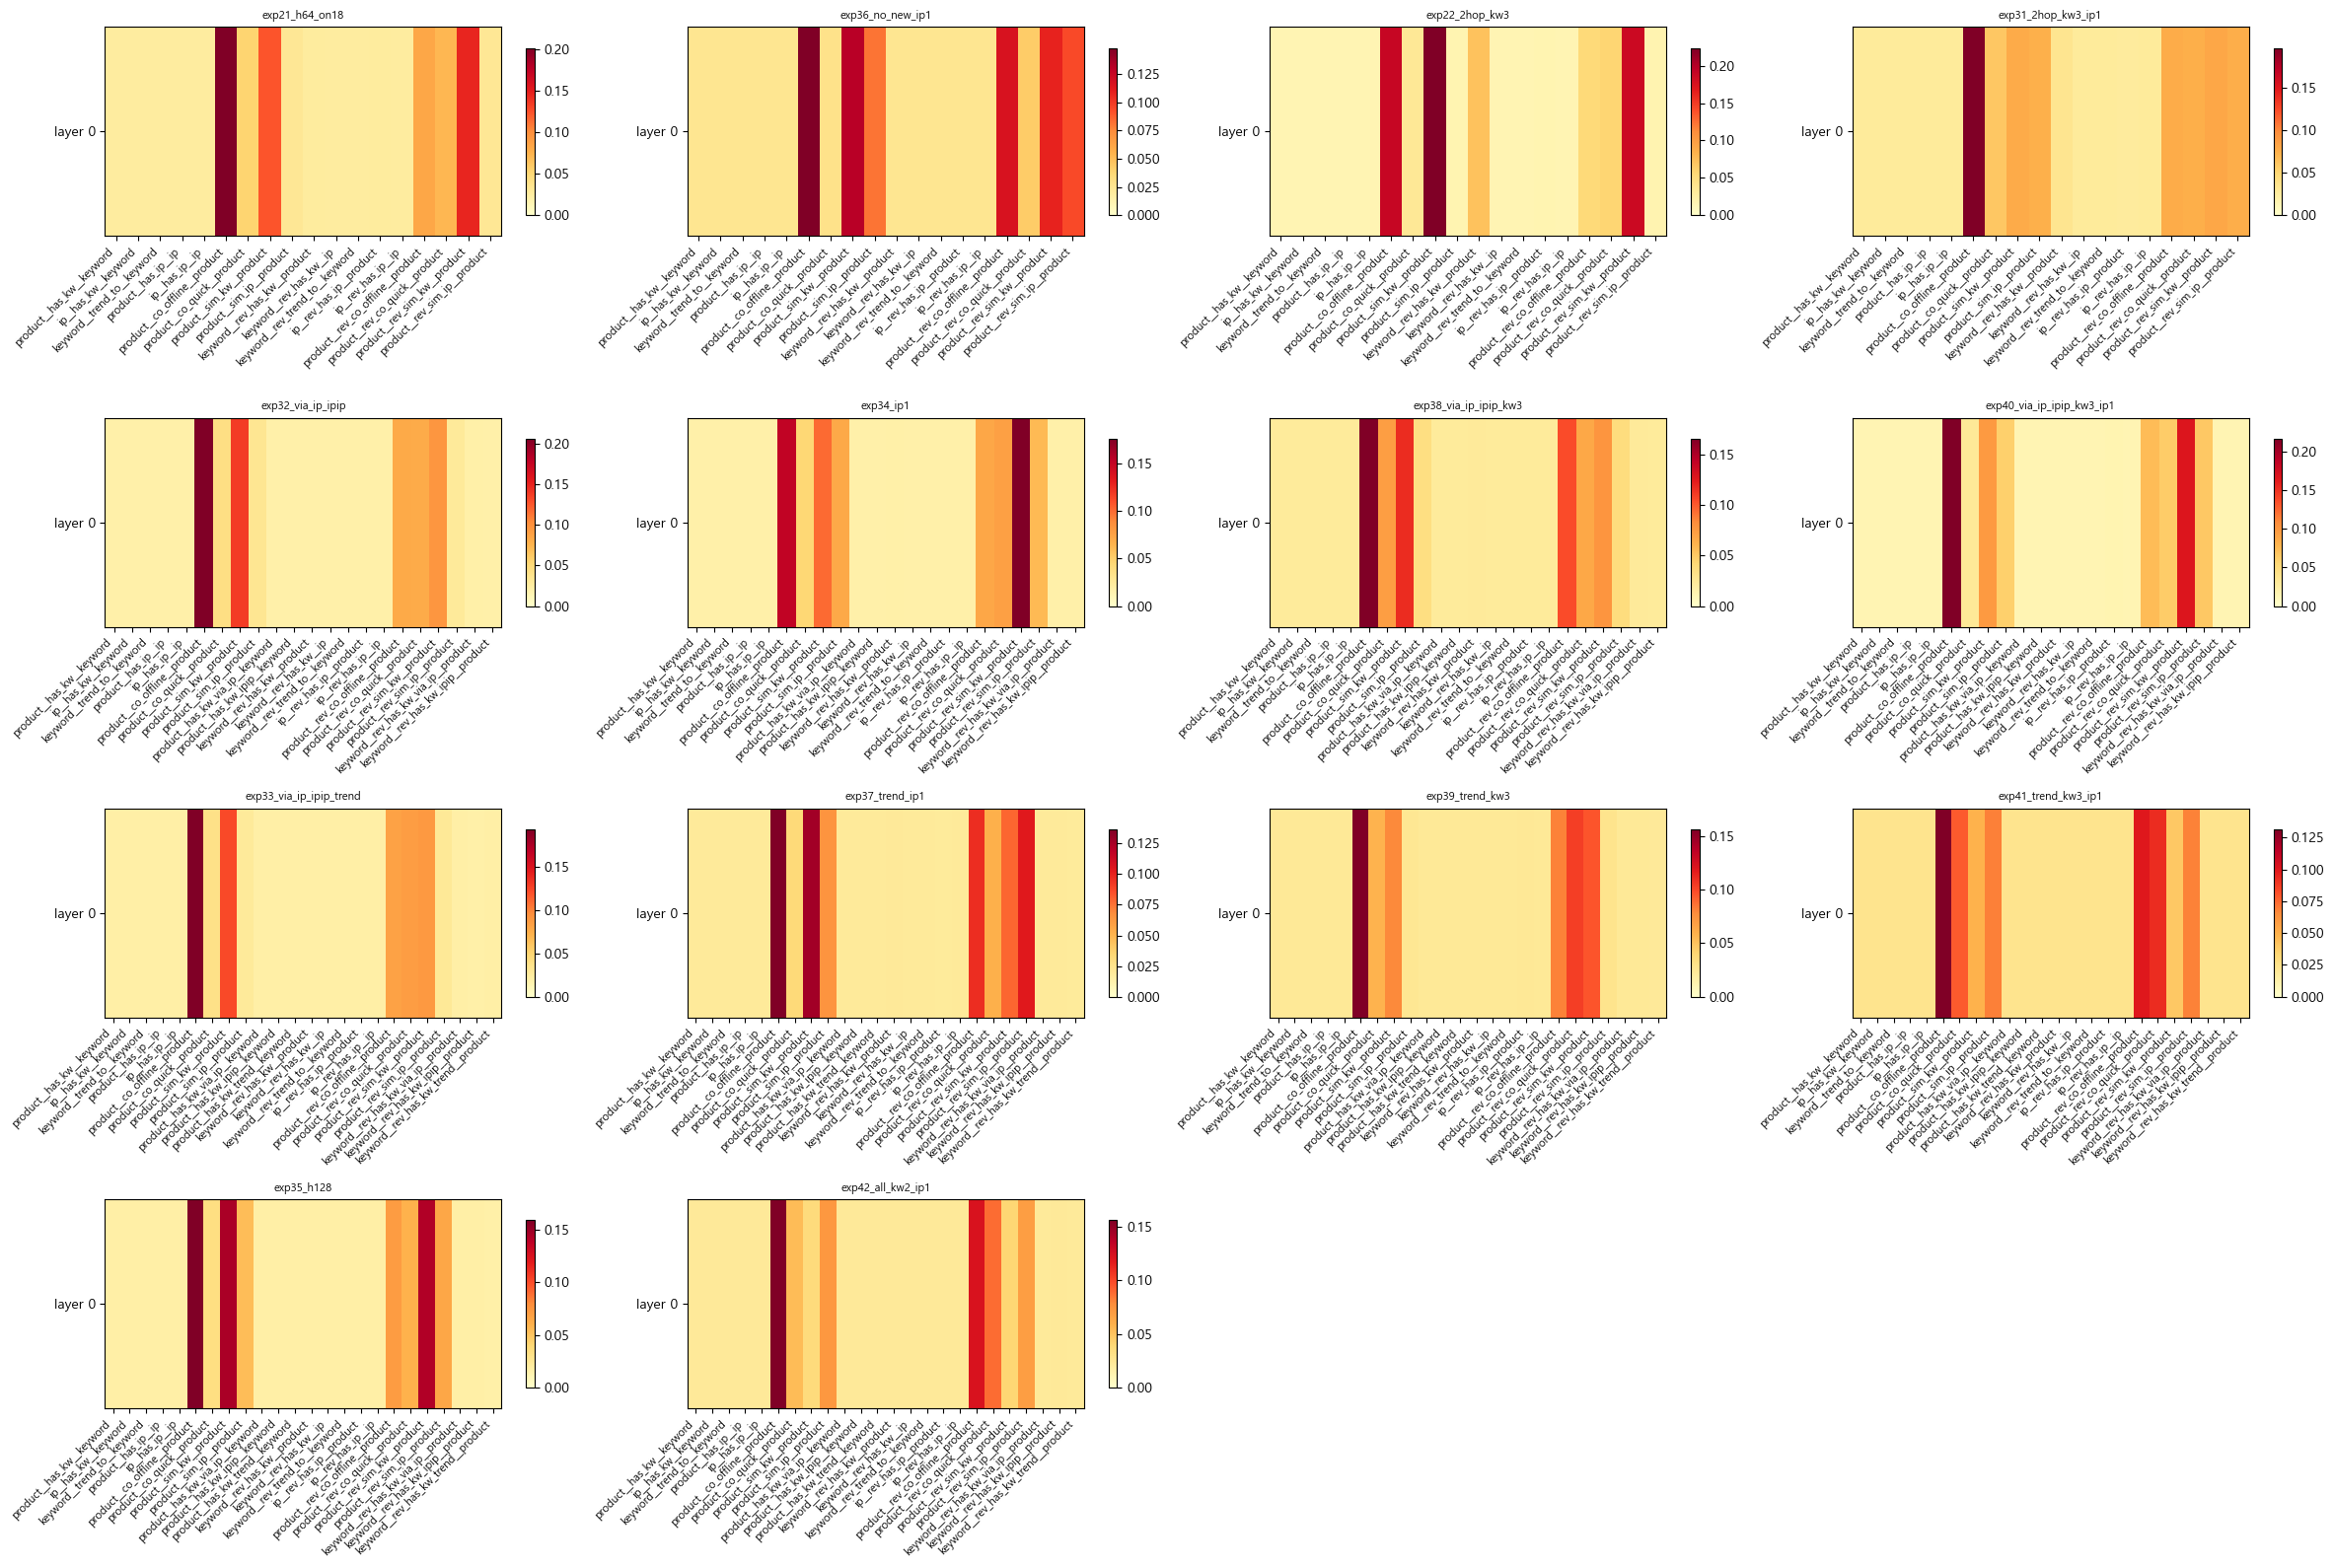

In [5]:
import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False

all_names = [
    'exp21_h64_on18', 'exp36_no_new_ip1', 'exp22_2hop_kw3', 'exp31_2hop_kw3_ip1',
    'exp32_via_ip_ipip', 'exp34_ip1', 'exp38_via_ip_ipip_kw3', 'exp40_via_ip_ipip_kw3_ip1',
    'exp33_via_ip_ipip_trend', 'exp37_trend_ip1', 'exp39_trend_kw3', 'exp41_trend_kw3_ip1',
    'exp35_h128', 'exp42_all_kw2_ip1',
]
df_all = compare_experiments(all_names)
df_show = df_all[df_all['exp'] != '[random baseline]'][['exp','val_pr_auc','test_pr_auc','test_auc_roc','test_f1']]
try:
    from IPython.display import display; display(df_show)
except Exception:
    print(df_show.to_string(index=False))

done_names = [n for n in all_names if os.path.exists(f'experiments/results/{n}/metrics.json')]
if done_names:
    n = len(done_names)
    ncols = min(n, 4)
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*6, nrows*4))
    axes = axes.flatten() if n > 1 else [axes]
    for ax, name in zip(axes, done_names):
        try:
            plot_alpha_heatmap(name, ax=ax)
            ax.set_title(name, fontsize=8)
        except Exception:
            ax.set_title(f'{name}\nα 없음')
    for ax in axes[n:]:
        ax.set_visible(False)
    plt.tight_layout()
    plt.show()